# 3.1 — Slope Everywhere, at the computer

Do the **pen-and-paper worksheet first**. Here you'll *see* what the tiny-$h$ nudge actually
does, build a derivative machine that works on any function, and meet a small miracle at the end.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")   # lets Python find our shared plotting helpers

import numpy as np
import matplotlib.pyplot as plt
from plots import plot_functions

## 1. Watch the nudge shrink

The slope formula $\frac{f(x+h)-f(x)}{h}$ draws a straight shortcut line between two points on
the curve. Watch what happens to that shortcut as $h$ shrinks — four snapshots, same point $x=3$
on $f(x)=x^2$:

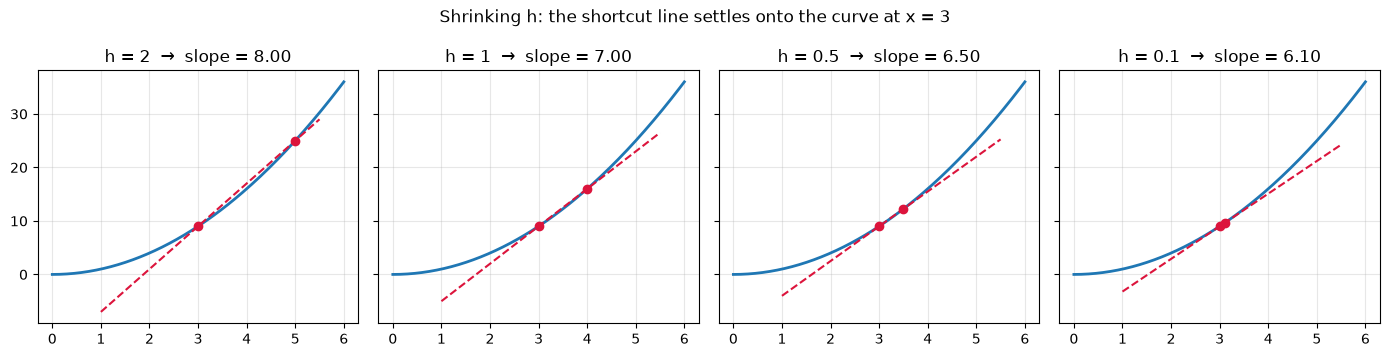

In [2]:
# zip(a, b) walks two lists in lockstep — one axis paired with one h value.
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
x0 = 3
for ax, h in zip(axes, [2, 1, 0.5, 0.1]):
    xs = np.linspace(0, 6, 200)
    ax.plot(xs, xs**2, linewidth=2)
    slope = ((x0 + h)**2 - x0**2) / h            # rise over run
    ax.plot([x0, x0 + h], [x0**2, (x0 + h)**2], "o", color="crimson")
    lx = np.linspace(1, 5.5, 2)                   # two x's are enough to draw a line
    ax.plot(lx, x0**2 + slope * (lx - x0), "--", color="crimson")
    ax.set_title(f"h = {h}  →  slope = {slope:.2f}")
    ax.grid(alpha=0.3)
fig.suptitle("Shrinking h: the shortcut line settles onto the curve at x = 3")
plt.tight_layout()
plt.show()

The slope estimates march toward **6** — the true steepness of $x^2$ right at $x=3$.
The dashed line in the last panel is (almost) the *tangent*: the line the curve would follow
if it stopped curving right there.

## 2. The derivative machine

Four lines of Python, works on **any** function you hand it:

In [3]:
def derivative(f, x, h=1e-6):    # functions can take FUNCTIONS as inputs — huge idea
    return (f(x + h) - f(x)) / h

def f(x):
    return x**2

# watch the estimate sharpen as h shrinks:
for h in [1, 0.1, 0.01, 0.001, 1e-6]:
    print(f"h = {h:<7}  slope of x² at x=3  ≈  {derivative(f, 3, h)}")

h = 1        slope of x² at x=3  ≈  7.0
h = 0.1      slope of x² at x=3  ≈  6.100000000000012
h = 0.01     slope of x² at x=3  ≈  6.009999999999849
h = 0.001    slope of x² at x=3  ≈  6.000999999999479
h = 1e-06    slope of x² at x=3  ≈  6.000001000927568


In [4]:
# YOUR TURN — check your worksheet Part B answers (problems 5–8) with the machine.
# Problem 5 is set up; add the others yourself.

print("P5: slope of x² at x=1   ≈", derivative(f, 1))

# P6: x² at x = -2
# P7: x³ at x = 2      (define  def g(x): return x**3  first)
# P8: x² at x = 0

P5: slope of x² at x=1   ≈ 2.0000009999243673


## 3. The derivative is a whole FUNCTION

Measure the slope of $x^2$ at *every* $x$ and plot the measurements. Worksheet Part D asked you
to prove they'd land on $2x$ — here's the visual verdict:

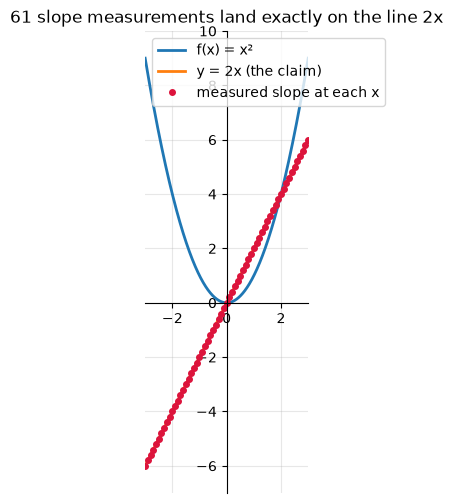

In [5]:
xs = np.linspace(-3, 3, 61)
slopes = [derivative(f, x) for x in xs]   # list comprehension: a for-loop squeezed into one line

ax = plot_functions({
    "f(x) = x²":        lambda x: x**2,
    "y = 2x (the claim)": lambda x: 2 * x,
}, xlim=(-3, 3), ylim=(-7, 10))
ax.plot(xs, slopes, "o", markersize=4, color="crimson", label="measured slope at each x")
ax.legend(loc="upper left")
ax.set_title("61 slope measurements land exactly on the line 2x")
plt.show()

## 4. 🌀 A glimpse of the deep end

Your machine works on functions nobody taught you rules for yet. Feed it the sine wave —
the wobble inside sound, light, and (later) the position-encodings of transformers —
and ask: *what is your slope, everywhere?*

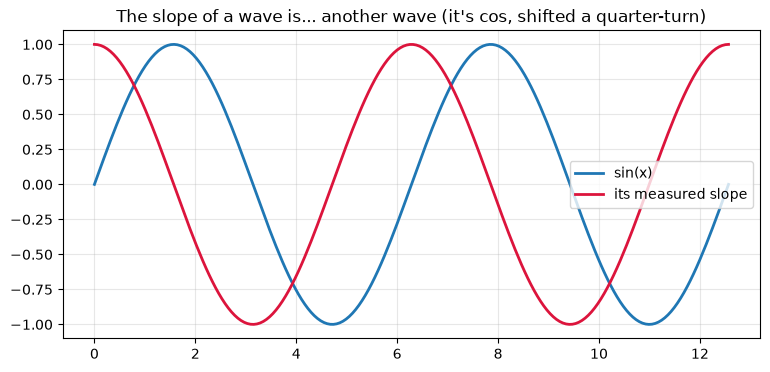

In [6]:
xs = np.linspace(0, 4 * np.pi, 200)
sin_slopes = [derivative(np.sin, x) for x in xs]

plt.figure(figsize=(9, 4))
plt.plot(xs, np.sin(xs), linewidth=2, label="sin(x)")
plt.plot(xs, sin_slopes, linewidth=2, color="crimson", label="its measured slope")
plt.grid(alpha=0.3)
plt.legend()
plt.title("The slope of a wave is... another wave (it's cos, shifted a quarter-turn)")
plt.show()

The derivative of a wave is the same wave, slid sideways — sine's slope IS cosine.
Nobody programmed that in; your nudge machine *discovered* it. Hidden structure, everywhere,
waiting to be measured.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 3.2 — the rules that make this instant.*